<a href="https://colab.research.google.com/github/YashviGupta15/Angular-Learn/blob/master/Pytorch_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. PyTorch Basics: Tensors, Tensor Operations, CPU vs GPU

Deep Learning models operate on **large collections of numbers**.
To support this efficiently, PyTorch introduces a fundamental data structure called a **tensor**.

At a mathematical level, tensors are nothing new:
- A scalar is a 0-dimensional tensor
- A vector is a 1-dimensional tensor
- A matrix is a 2-dimensional tensor
- Higher-order tensors extend this idea further

What makes PyTorch tensors special is **not their shape**, but their **behavior**.

A PyTorch tensor can:
1. Store numerical data
2. Participate in vectorized mathematical operations
3. Track how it was created (for gradient computation)
4. Move seamlessly between different compute devices (CPU and GPU)

In classical Machine Learning, we often worked with NumPy arrays.
While NumPy is excellent for numerical computation, it has two major limitations
when moving toward Deep Learning:
- It does not track gradients
- It does not natively support GPU acceleration for general computation

PyTorch tensors address both of these limitations.

### Tensors vs NumPy Arrays
Conceptually:
- NumPy arrays focus on **numerical values**
- PyTorch tensors focus on **numerical values + computation history**

This difference becomes critical once we start training neural networks.

---

### Tensor Properties

Every tensor in PyTorch has three properties that directly affect model behavior:

1. **Shape**
   - Determines how tensors interact in matrix operations
   - Most runtime errors in deep learning are shape-related

2. **Data Type (dtype)**
   - Determines numerical precision (e.g., float32, float64)
   - Deep learning models almost always use floating-point tensors

3. **Device**
   - Specifies where computation occurs (CPU or GPU)
   - PyTorch allows the same code to run on different hardware

Understanding these properties early prevents silent bugs later.

---

### Tensor Operations

All neural network computations reduce to:
- Elementwise operations
- Dot products
- Matrix multiplications
- Broadcasting

Broadcasting allows PyTorch to apply operations between tensors
of different shapes without explicit loops.

This is not a convenience feature — it is essential for:
- Computational efficiency
- Memory efficiency
- Parallel execution

---

### CPU vs GPU Execution

Modern deep learning relies heavily on GPUs because:
- Neural networks involve massive parallel computations
- GPUs are optimized for matrix and tensor operations

PyTorch introduces a **device abstraction**, meaning:
- The same tensor code works on CPU or GPU
- Data must reside on the same device as the computation

PyTorch does **not** automatically move tensors between devices.
This design choice forces the user to be explicit and avoids silent performance errors.

Understanding device placement now will be crucial when training larger models later.


In [ ]:
import torch
import numpy as np

# Creating tensors
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor(np.array([4.0, 5.0, 6.0]))

print("Tensor y:", y)
print("Shape:", y.shape)
print("Data type:", y.dtype)
print("Device:", y.device)

# Tensor operations
a = torch.tensor([1.0, 2.0])
b = torch.tensor([3.0, 4.0])

dot_product = torch.dot(a, b)

M = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])
v = torch.tensor([1.0, 1.0])

matrix_vector = torch.matmul(M, v)

print("\nDot product:", dot_product)
print("Matrix-vector product:", matrix_vector)

# Device management
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_device = x.to(device)

print("\nComputation device:", device)
print("Tensor x is on:", x_device.device)
print(torch.cuda.get_device_name(0))


Tensor y: tensor([4., 5., 6.], dtype=torch.float64)
Shape: torch.Size([3])
Data type: torch.float64
Device: cpu

Dot product: tensor(11.)
Matrix-vector product: tensor([3., 7.])

Computation device: cuda
Tensor x is on: cuda:0
NVIDIA GeForce RTX 4060 Laptop GPU


### Concept-Check Questions

1. Why are floating-point numbers preferred over integers in deep learning models?
2. What role does the `shape` of a tensor play in neural network computations?
3. How is a PyTorch tensor fundamentally different from a NumPy array?
4. Why does PyTorch require tensors and models to be explicitly moved to the GPU?
5. What problem does broadcasting solve in tensor operations?


## 2. Autograd: Automatic Differentiation in PyTorch

In classical Machine Learning, gradients are derived **analytically**.
For simple models like linear regression, this is manageable.
However, as models grow deeper and more complex, manual differentiation becomes:
- Error-prone
- Difficult to scale
- Hard to debug

Deep Learning relies on **gradient-based optimization**, which requires computing
derivatives of a loss function with respect to potentially millions of parameters.

PyTorch solves this problem using **automatic differentiation**, commonly referred to as *autograd*.

---

### What is Autograd?

Autograd is PyTorch’s engine for computing derivatives automatically.

Instead of computing gradients symbolically, PyTorch:
1. Records all operations performed on tensors
2. Builds a **computational graph** during the forward pass
3. Applies the **chain rule** automatically during the backward pass

This process is known as **reverse-mode automatic differentiation**.

---

### Computational Graph

A computational graph is a directed graph where:
- Nodes represent tensor operations
- Edges represent data dependencies

Every operation on a tensor with `requires_grad=True` is tracked.
The graph is built **dynamically**, meaning:
- It is created during execution
- It can change from iteration to iteration

This dynamic nature is one of PyTorch’s key strengths.

---

### Enabling Gradient Tracking

By default, PyTorch does **not** track gradients.

To include a tensor in gradient computation, we must explicitly set:
```python
requires_grad = True


In [ ]:



### 💻 CODE CELL — Autograd Demonstration (Single Consolidated Cell)


import torch

# Scalar example
x = torch.tensor(2.0, requires_grad=True)

# Forward computation
y = x**2 + 3*x + 1

# Backward pass
y.backward()

print("Value of y:", y.item())
print("Gradient dy/dx:", x.grad)

# Reset gradient
x.grad.zero_()

# Vector example
w = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

z = torch.sum(w**2)
z.backward()

print("\nVector w:", w)
print("Gradient dz/dw:", w.grad)


Value of y: 11.0
Gradient dy/dx: tensor(7.)

Vector w: tensor([1., 2., 3.], requires_grad=True)
Gradient dz/dw: tensor([2., 4., 6.])


## 3. Loss Functions, Optimizers, and Training Loop Flow

Now that we understand how PyTorch computes gradients using autograd,
we must answer the central question:

How do we use those gradients to actually train a model?

Training in deep learning consists of three essential components:

1. A Model
2. A Loss Function
3. An Optimizer

These components interact through a structured procedure known as the training loop.

---

## 3.1 Loss Function

A loss function measures the difference between:
- Model predictions
- True target values

Mathematically:

Loss = f(predictions, targets)

The objective of training is to minimize this loss.

For regression problems, we commonly use Mean Squared Error (MSE):

MSE = (1/n) Σ (y_pred - y_true)^2

The loss must satisfy:
- It must be differentiable
- It must return a scalar
- It must connect the model output to the target

The loss is the starting point of backpropagation.

---

## 3.2 Optimizer

Once gradients are computed, parameters must be updated.

The optimizer defines how parameters move in order to reduce the loss.

For example, in Stochastic Gradient Descent (SGD):

θ = θ - η ∇L

Where:
- θ = parameters
- η = learning rate
- ∇L = gradient of loss

Important:
- Autograd computes gradients.
- The optimizer uses those gradients to update parameters.
- The optimizer does NOT compute gradients.

---

## 3.3 Training Loop Flow

Every deep learning model follows this same structure:

Step 1: Forward pass  
    Compute predictions

Step 2: Compute loss  
    Measure prediction error

Step 3: Backward pass  
    Compute gradients using autograd

Step 4: Optimizer step  
    Update parameters

Step 5: Zero gradients  
    Reset gradients to prevent accumulation

The order is critical.

Failure to reset gradients leads to incorrect updates,
because PyTorch accumulates gradients by default.

We will now visualize:
- Proper convergence
- What happens when zero_grad() is removed


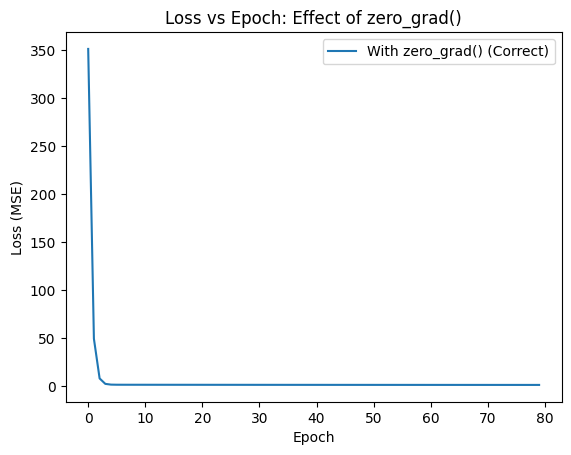

Losses at each Epoch: [351.44317626953125, 49.280059814453125, 7.878341197967529, 2.201810836791992, 1.4198250770568848, 1.3084930181503296, 1.2891252040863037, 1.2824379205703735, 1.2775675058364868, 1.2730244398117065, 1.268602728843689, 1.2642725706100464, 1.2600288391113281, 1.255868911743164, 1.2517911195755005, 1.2477939128875732, 1.2438757419586182, 1.240035057067871, 1.2362699508666992, 1.232579231262207, 1.228961706161499, 1.2254153490066528, 1.2219393253326416, 1.2185324430465698, 1.215192198753357, 1.2119179964065552, 1.208708643913269, 1.2055623531341553, 1.2024785280227661, 1.199455738067627, 1.1964924335479736, 1.1935877799987793, 1.190740704536438, 1.187949776649475, 1.1852134466171265, 1.1825318336486816, 1.1799030303955078, 1.1773260831832886, 1.174800157546997, 1.1723241806030273, 1.1698969602584839, 1.1675177812576294, 1.1651854515075684, 1.162899374961853, 1.1606582403182983, 1.1584616899490356, 1.156308650970459, 1.1541978120803833, 1.15212881565094, 1.150100827217

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------------------------
# Synthetic dataset
# ---------------------------
torch.manual_seed(0)
X = torch.linspace(0, 10, 100).unsqueeze(1)
y = 3*X + 2 + torch.randn(100, 1)

criterion = nn.MSELoss()
epochs = 80

# ==========================================================
# RUN A: Correct Training Loop (with zero_grad)
# ==========================================================
torch.manual_seed(0)
model_A = nn.Linear(1, 1)
optimizer_A = optim.SGD(model_A.parameters(), lr=0.02)

losses_A = []

for epoch in range(epochs):
    predictions = model_A(X)
    loss = criterion(predictions, y)

    loss.backward()
    optimizer_A.step()
    optimizer_A.zero_grad()

    losses_A.append(loss.item())

# ==========================================================
# RUN B: Incorrect Training Loop (WITHOUT zero_grad)
# ==========================================================
#torch.manual_seed(0)
#model_B = nn.Linear(1, 1)
#optimizer_B = optim.SGD(model_B.parameters(), lr=0.01)

#losses_B = []

#for epoch in range(epochs):
   # predictions = model_B(X)
   # loss = criterion(predictions, y)

   # loss.backward()
   # optimizer_B.step()
    # optimizer_B.zero_grad()  # intentionally removed

    #losses_B.append(loss.item())

# ---------------------------
# Plot Loss Curves
# ---------------------------
plt.figure()
plt.plot(losses_A, label="With zero_grad() (Correct)")
#plt.plot(losses_B, label="Without zero_grad() (Incorrect)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epoch: Effect of zero_grad()")
plt.legend()
plt.show()

# Final parameter comparison
print("Losses at each Epoch:", losses_A)
print("Final Loss (Correct):", losses_A[-1])
#print("Final Loss (No zero_grad):", losses_B[-1])

print("\nLearned parameters (Correct):",
      "w =", model_A.weight.item(),
      ", b =", model_A.bias.item())

# print("Learned parameters (No zero_grad):",
#       "w =", model_B.weight.item(),
#       ", b =", model_B.bias.item())


### Concept-Check Questions

1. Why does the loss decrease in the correct training loop?
2. What pattern do you observe in the loss curve without zero_grad()?
3. Why is it important to use the same random seed for both experiments?
4. What does gradient accumulation mean mathematically?
5. If training becomes unstable, which components of the training loop should be checked first?
6. How would increasing the learning rate affect the shape of the loss curve?


## 4. Building and Training a Neural Network using nn.Module

Until now, we trained a simple linear model:

    y = wx + b

But this is only a special case of a more general transformation:

    Y = XW + b

Where:
- X ∈ ℝ^(batch_size × in_features)
- W ∈ ℝ^(out_features × in_features)
- b ∈ ℝ^(out_features)

This is the fundamental building block of neural networks.

---

## 4.1 From Scalar Linear Regression to Matrix Transformation

Previously:
    y = wx + b

In matrix form (for batch input):

    Y = XW^T + b

If:
- X has shape (N, d)
- W has shape (k, d)

Then:
- Output has shape (N, k)

So `nn.Linear(d, k)` represents:

    A learnable matrix W ∈ ℝ^(k × d)
    A learnable bias b ∈ ℝ^(k)

This is NOT deep learning magic.
It is matrix multiplication.

---

## 4.2 Stacking Linear Transformations

A neural network with one hidden layer performs:

    H = XW1^T + b1
    A = activation(H)
    Y = AW2^T + b2

Each layer:
- Applies a linear transformation
- Optionally applies a non-linear activation

The power of neural networks comes from:
- Repeated matrix transformations
- Non-linear activations between them

Without activation, stacking linear layers reduces to one linear layer.

---

## 4.3 What nn.Module Does

`nn.Module` provides:

- A structured way to define learnable matrices
- Automatic parameter registration
- Clean forward computation definition

Instead of manually defining w and b,
we define layers as matrix transformations.

This makes scaling to deep networks manageable.

---

We will now:
1. Define a simple neural network
2. Inspect its weight matrices
3. Train it
4. Visualize convergence


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------------------------
# Define Neural Network
# ---------------------------
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()

        # First linear transformation
        self.layer1 = nn.Linear(1, 8)  # W1: (8 × 1)

        # Non-linear activation
        self.relu = nn.ReLU()

        # Second linear transformation
        self.layer2 = nn.Linear(8, 1)  # W2: (1 × 8)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


model = SimpleNN()

# Inspect parameters
print("Layer1 weight shape:", model.layer1.weight.shape)
print("Layer2 weight shape:", model.layer2.weight.shape)


Layer1 weight shape: torch.Size([8, 1])
Layer2 weight shape: torch.Size([1, 8])


### Matrix Interpretation

For input X ∈ ℝ^(100 × 1):

Layer 1:
    W1 ∈ ℝ^(8 × 1)
    Output H ∈ ℝ^(100 × 8)

Activation:
    A = ReLU(H)

Layer 2:
    W2 ∈ ℝ^(1 × 8)
    Output Y ∈ ℝ^(100 × 1)

So the network computes:

    Y = ReLU(XW1^T + b1)W2^T + b2

This is simply:
- Matrix multiplication
- Non-linearity
- Matrix multiplication


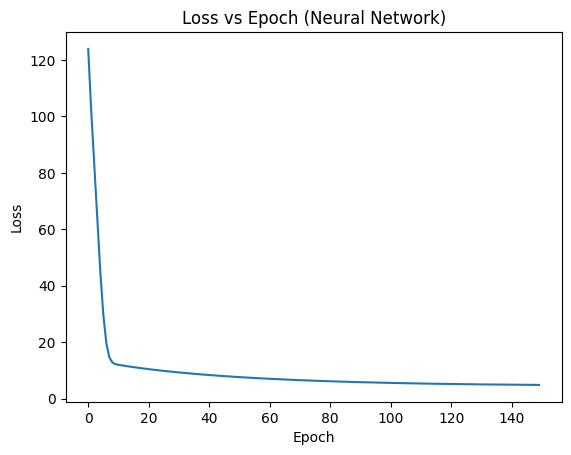

In [ ]:
# Synthetic nonlinear dataset
torch.manual_seed(0)
X = torch.linspace(-5, 5, 200).unsqueeze(1)
y = X**2 + torch.randn(200, 1) * 2  # nonlinear target

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 150
losses = []

for epoch in range(epochs):
    predictions = model(X)
    loss = criterion(predictions, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    losses.append(loss.item())

# Plot loss curve
plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch (Neural Network)")
plt.show()
